In [ ]:
using NeutralAtoms
using CSV
using DataFrames
using Plots
include("../config5P_flattop.jl")

get_default_cfg2gauss (generic function with 1 method)

In [ ]:
_, cfg_CZ = get_5P_config() 

cfg_CZ.ψ0 = (ket_0 + ket_1) ⊗ (ket_0 + ket_1) / 2
cfg_CZ.n_samples = 1;
cfg_CZ.atom_params[2] = 0.1; #temperature  
cfg_CZ.error_options = Dict("laser_noise" => false,"spontaneous_decay_intermediate" => false,"spontaneous_decay_rydberg" => false,
"atom_motion" => false,"free_motion" => false,"xy_motion" => false,"z_motion" => false,"Doppler" => false);

println("Δ = $(round(cfg_CZ.ΔtoΩ; digits=6)), ξ = $(round(cfg_CZ.ξ; digits=6))")

ψ = pure_simulation_czlp(cfg_CZ)[end]; 

basis = [ket_0 ⊗ ket_0, ket_0 ⊗ ket_1, ket_1 ⊗ ket_0, ket_1 ⊗ ket_1]
state = [dagger(st) * ψ for st in basis] 

println("Ampls difference: ", abs.(state) .- ones(4)./2)
println("Phases on states: ", angle.(state) ) 
println("ϕ_RZ = ", -(angle(state[2])+angle(state[3]))/2, " phase on |11> = ", angle(state[4]) - angle(state[2])-angle(state[3]), " err_norm = ",norm(abs.(state) .- ones(4)./2))
angle(state[2])


Δ = 0.377371, ξ = 4.1325
Ampls difference: [0.0, -0.0053897091443488865, -0.007234014423852242, -0.0032816138654941374]
Phases on states: [0.0, -1.9020638630494813, -1.9845665348617456, -0.7450608374235387]
ϕ_RZ = 1.9433151989556134 phase on |11> = 3.1415695604876883 err_norm = 0.00959942284241004


-1.9020638630494813

In [ ]:
Pr_r = load_QO_operator("data\\rydberg_rabi_1.jld2");

In [ ]:
cfg_rd,_=get_5P_config()
t_span=cfg_rd.tspan;

In [ ]:
data = DataFrame(Column1 = t_span, Column2 = Pr_r)
CSV.write("rydberg_rabi_1.csv", data)

"rydberg_rabi_2.csv"

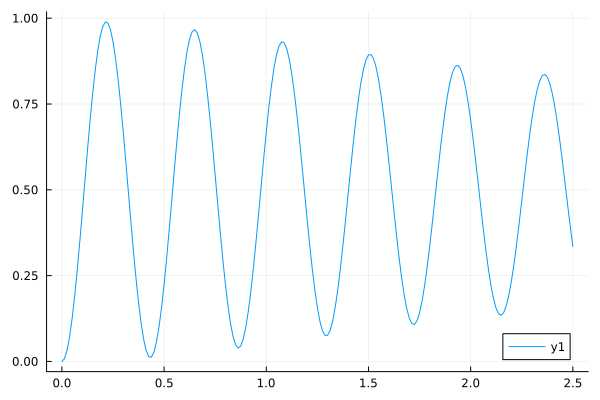

In [5]:
plot(t_span,Pr_r)

In [2]:
ρ = load_QO_operator("data\\rho_distr.jld2");

0.9401268107410922 1.741


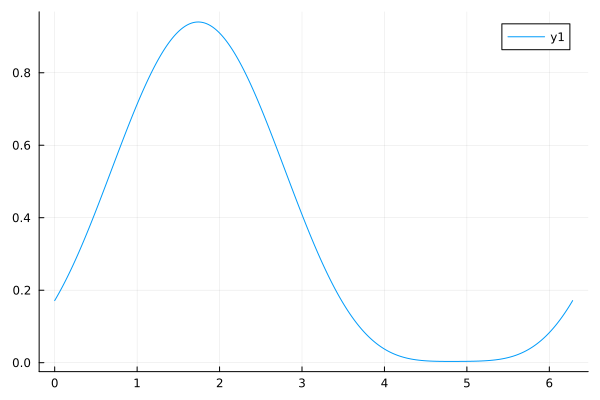

In [ ]:
_, cfg_CZ = get_6P_config();
ϕs =  [0.0:0.001:2π;];
Fids = [get_fidelity_with_rz_phi(ρ, cfg_CZ.ψ0, ϕ) for ϕ in ϕs];
println(maximum(Fids), " ", ϕs[argmax(Fids)])
plot(ϕs, Fids)